# Code deformation for [144, 12, 6] BB code

In [12]:
import graph_helper_functions
from graph_helper_functions import *
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import igraph as ig
from sympy.abc import x, y
from qldpc import codes, circuits
from qldpc.objects import Pauli
import numpy as np
from collections import defaultdict, deque

## Example for a logical Z

BB code with [n, k, d] = [144, 12, 6]
Logical qubit indices:  [ 5  6  7 10 11 12 13 16 17 24 30 36 37 56]
Port vertice indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Edges added to auxiliary system:  21
Weight of new X stabilizers:  [3, 3, 4, 4, 5, 5, 6, 6]
Weight of new Z stabilizers:  [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
The deformed BB code: 
Qubits: [0,1, ... 92] with 72 original BB code qubits [0, 1, ..., 71] and 21 added edge qubits [72, 73, ... 92]
Parity check matrix H_def of size (94, 186): 
[[0 1 1 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]]


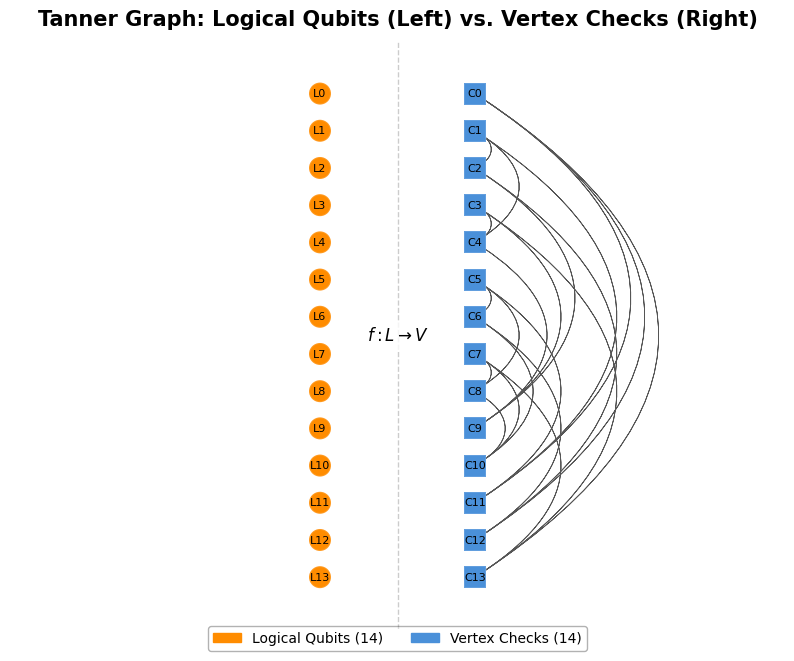

In [14]:
a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 6, y: 6}
BB_code = codes.BBCode(orders=orders, poly_a=a, poly_b=b)
print("BB code with [n, k, d] = [144, 12, 6]")
logicals = BB_code.get_logical_ops(Pauli.Z)
# logical qubits, set "L"
logical_qubits = logicals[0]
logical_qubits_index = np.where(logicals[0] == 1)[0]
n_L = len(logical_qubits_index)

# syndrome measurements from parity check matrix
port_vertices = np.array(range(len(logical_qubits_index)))
n_L = len(logical_qubits_index)
n_vertices = 2*n_L  # this includes port vertices + qubits in the graph 
g = ig.Graph(n_vertices, edges = [])

g["title"] = "Logical Qubits and Vertex Checks"
g.vs["is_logical"] = [True] * n_L + [False] * n_L
g.vs["label"]      = [f"L{i}" for i in range(n_L)] + [f"C{i}" for i in range(n_L)]
g.vs["is_check"] = [False] * n_L + [True] * n_L

print("Logical qubit indices: ", logical_qubits_index)
print("Port vertice indices:", port_vertices)

# Spacing constants
COLUMN_GAP = 5  # Horizontal distance between the two lines
VERTICAL_STEP = 1.2  # Vertical distance between nodes in a line

total_height = (n_L - 1) * VERTICAL_STEP
y_center = total_height / 2

logical_x = 0
logical_positions = [
    (logical_x, y_center - i * VERTICAL_STEP) 
    for i in range(n_L)
]

check_x = logical_x + COLUMN_GAP
check_positions = [
    (check_x, y_center - i * VERTICAL_STEP) 
    for i in range(n_L)
]

layout = ig.Layout(logical_positions + check_positions)

vertex_colors = ["#FF8C00" if v["is_logical"] else "#4A90D9" for v in g.vs]
vertex_sizes  = [22 for v in g.vs]
vertex_shapes = ["rectangle" if v["is_check"] else "circle" for v in g.vs]

BB_qubit_vertex_check_map = mapping = {val: i for i, val in enumerate(logical_qubits_index)}

def f(q):
    return q + n_L

def f_inverse(q):
    return q-n_L

# compute which vertices should be connected based on anticommutation with X checks
checks = BB_code.matrix
X_checks = checks[:, :72]


X_check_pairs = []
for i, check in enumerate(X_checks):
    pair = np.where((logical_qubits == 1) & (check == 1))[0] 
    if len(pair) == 2:
        (v1, v2) = pair
        v1 = BB_qubit_vertex_check_map[v1]
        v2 = BB_qubit_vertex_check_map[v2]
        X_check_pairs.append((f(v1), f(v2)))


for pair in X_check_pairs:
    g.add_edge(*pair)

n_edges = len(g.get_edgelist())
print("Edges added to auxiliary system: ", n_edges)



fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.set_aspect('equal')

ig.plot(
    g,
    target=ax,
    layout=layout,
    vertex_size=vertex_sizes,
    vertex_color=vertex_colors,
    vertex_shape = vertex_shapes,
    vertex_frame_width=1.5,
    vertex_frame_color="#ffffff22",
    vertex_label=g.vs["label"] if "label" in g.vs.attributes() else None,
    vertex_label_size=8.0,
    vertex_label_color="black",
    edge_width=0.6,
    edge_curved=[1]*n_L,
    edge_color="#555555"       
    
)
all_x = [pos[0] for pos in logical_positions + check_positions]
all_y = [pos[1] for pos in logical_positions + check_positions]
padding = 10
ax.set_xlim(min(all_x) - padding, max(all_x) + padding)

y_mid = (min(all_y) + max(all_y)) / 2

# Dividing line exactly in the middle
div_x = logical_x + (COLUMN_GAP / 2)
ax.axvline(x=div_x, color="#00000033", linewidth=1, linestyle="--")

ax.text(
    div_x, y_mid, r'$f: L \to V$',
    ha='center', va='center',
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
)

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(color="#FF8C00", label=f"Logical Qubits ({n_L})"),
    mpatches.Patch(color="#4A90D9", label=f"Vertex Checks ({n_L})"),
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    framealpha=0.3,
    facecolor="white",           
    edgecolor="#00000033",      
    labelcolor="black",          
    fontsize=10,
)

ax.set_title(
    "Tanner Graph: Logical Qubits (Left) vs. Vertex Checks (Right)",
    color="black", fontsize=15, pad=12, fontweight="bold"
)

#print(stimcode)
edge_qubits = np.arange(n_edges)
cycles_edges = find_short_cycle_basis([tuple(a) for a in X_check_pairs], return_edges=True)
new_X_syndromes = []
for cyc in cycles_edges:
    support = []
    for u, v in cyc:
        eid = g.get_eid(u, v, directed=False)
        support.append(72 + eid)
    new_X_syndromes.append(support)

# BB code qubits [0, 71] + Ancillary system [72, ]
BB_qubits = np.arange(72)
ancilla_qubits = np.arange(72, 72+n_edges)
ancilla_system = np.arange(72+n_edges)

new_Z_syndromes = []
for v in range(n_vertices//2, 28):  # vertices 13–27 (0-based)
    Z_check = g.incident(v)  
    Z_check = [i + 72 for i in Z_check] # add edge qubits touching vertex
    Z_check.append(int(logical_qubits_index[f_inverse(v)])) # add logical support qubit 
    new_Z_syndromes.append(Z_check)


# print(new_X_syndromes[0])
# print(new_Z_syndromes)

print("Weight of new X stabilizers: ", sorted([len(i) for i in new_X_syndromes])) # paper had  [3, 3, 5, 5, 5, 6, 7, 9]. We should put an upper limit 
print("Weight of new Z stabilizers: ", sorted([len(i) for i in new_Z_syndromes]))
n_data = 72
n_qubits = n_data + n_edges

checks = np.array(BB_code.matrix, dtype=int)

Hx_all = checks[:, :n_data]
Hz_all = checks[:, n_data:]

Hx_old = Hx_all[np.any(Hx_all, axis=1)]
Hz_old = Hz_all[np.any(Hz_all, axis=1)]

Hx_new = np.zeros((len(new_X_syndromes), n_qubits), dtype=int)
for i, support in enumerate(new_X_syndromes):
    Hx_new[i, support] = 1

Hz_new = np.zeros((len(new_Z_syndromes), n_qubits), dtype=int)
for i, support in enumerate(new_Z_syndromes):
    Hz_new[i, support] = 1

Hx_old_padded = deform_old_x_checks_with_graph_edges(
    g=g,
    Hx_all=Hx_all,
    logical_qubits=logical_qubits,
    logical_qubits_index=logical_qubits_index,
    n_data=72,
    n_edges=n_edges,
    n_L=n_L,
)
Hz_old_padded = np.pad(Hz_old, ((0, 0), (0, n_edges)), mode="constant")

Hx_def = np.vstack([Hx_old_padded, Hx_new])
Hz_def = np.vstack([Hz_old_padded, Hz_new])
H_def = np.block([[Hx_def, np.zeros((np.shape(Hx_def)[0], n_qubits), dtype=int)], [np.zeros((np.shape(Hz_def)[0], n_qubits), dtype=int), Hz_def]])

print("The deformed BB code: ")
print(f"Qubits: [0,1, ... {n_qubits-1}] with {n_data} original BB code qubits [0, 1, ..., {n_data-1}] and {n_edges} added edge qubits [{n_data}, {n_data+1}, ... {n_qubits-1}]")
print(f"Parity check matrix H_def of size {np.shape(H_def)}: ")
print(H_def)

In [3]:

comm = (Hz_def @ Hx_def.T) % 2
print("Deformed stabilizers commute? ", np.all(comm==0))
deformed_logical = np.pad(logical_qubits, (0, n_edges))

Deformed stabilizers commute?  True


In [4]:
comm = (Hz_def @ Hx_def.T) % 2
print("Deformed stabilizers commute? ", np.all(comm==0))
deformed_logical = np.pad(logical_qubits, (0, n_edges))
coeffs = gf2_solve_left(Hz_def, deformed_logical)

print("Original logical is in stabilizer group:", np.any(coeffs==1))
print("Combination of checks:", np.where(coeffs == 1)[0])
# recon = (coeffs @ Hz_def) % 2
# print("Reconstruction correct?", np.array_equal(recon, deformed_logical % 2))

Deformed stabilizers commute?  True
Original logical is in stabilizer group: True
Combination of checks: [36 37 38 39 40 41 42 43 44 45 46 47 48 49]


# Function for deforming BB code for logical operators

In [5]:
def deform_code_for_logical(code, basis, logical_index):
    H = np.asarray(code.matrix)
    logical_ops = to_gf2(code.get_logical_ops(basis))
    logical_qubits = logical_ops[logical_index]
    logical_qubits_index = np.where(logical_qubits == 1)[0]

    n_data = logical_qubits.shape[0]

    qubit_to_vertex = {int(q): i for i, q in enumerate(logical_qubits_index)}
    vertex_to_qubit = {i: int(q) for i, q in enumerate(logical_qubits_index)}
    n_vertices = len(logical_qubits_index)

    g = ig.Graph(n_vertices, edges=[])

    if basis == Pauli.Z:
        H_basis_all = H[:, n_data:]
        H_opposite_basis_all = H[:, :n_data]
    else:
        H_basis_all = H[:, :n_data]
        H_opposite_basis_all = H[:, n_data:]

    edge_set = set()
    for check in H_opposite_basis_all:
        pair = np.where((logical_qubits == 1) & (check == 1))[0]
        if len(pair) == 2:
            v1 = qubit_to_vertex[int(pair[0])]
            v2 = qubit_to_vertex[int(pair[1])]
            edge_set.add(normalize_edge(v1, v2))

    if edge_set:
        g.add_edges(list(edge_set))

    comps = g.components()
    if len(comps) > 1:
        reps = [comp[0] for comp in comps]
        for i in range(len(reps) - 1):
            e = normalize_edge(reps[i], reps[i + 1])
            if not g.are_adjacent(*e):
                g.add_edge(*e)

    H_basis_nonzero = H_basis_all[np.any(H_basis_all, axis=1)]
    max_cycle_weight = int(np.max(np.sum(H_basis_nonzero, axis=1))) if len(H_basis_nonzero) else 4
    max_cycle_weight = max(max_cycle_weight, 3)

    cycles_edges = find_short_cycle_basis(
        [tuple(map(int, e)) for e in g.get_edgelist()],
        return_edges=True,
    )

    cycles_edges = split_heavy_cycles(
        cycles_edges=cycles_edges,
        max_cycle_weight=max_cycle_weight,
        g=g,
    )

    final_edgelist = [normalize_edge(*e) for e in g.get_edgelist()]
    edge_to_eid = {e: eid for eid, e in enumerate(final_edgelist)}

    n_edges = len(final_edgelist)
    n_qubits = n_data + n_edges

    H_opposite_basis_new = np.zeros((len(cycles_edges), n_qubits), dtype=np.uint8)
    for i, cyc in enumerate(cycles_edges):
        for e in cyc:
            eid = edge_to_eid[normalize_edge(*e)]
            H_opposite_basis_new[i, n_data + eid] ^= 1

    H_basis_new = np.zeros((n_vertices, n_qubits), dtype=np.uint8)
    for v in range(n_vertices):
        H_basis_new[v, vertex_to_qubit[v]] = 1
        for eid in g.incident(v):
            H_basis_new[v, n_data + eid] ^= 1

    H_basis_old = H_basis_all[np.any(H_basis_all, axis=1)]
    H_basis_old_padded = np.pad(H_basis_old, ((0, 0), (0, n_edges)), mode="constant").astype(np.uint8)

    H_opposite_basis_old_padded = deform_old_opposite_basis_checks_with_graph_edges(
        g=g,
        H_opposite_basis_all=H_opposite_basis_all,
        logical_qubits=logical_qubits,
        logical_qubits_index=logical_qubits_index,
        n_data=n_data,
    )

    H_opposite_basis_def = np.vstack([H_opposite_basis_old_padded, H_opposite_basis_new]) % 2
    H_basis_def = np.vstack([H_basis_old_padded, H_basis_new]) % 2

    return n_qubits, n_data, n_edges, H_basis_def, H_opposite_basis_def

In [6]:
i=0
logical = BB_code.get_logical_ops(Pauli.X)[i]
print("The logical is: ", logical)
n_qubits, n_data, n_edges, Hz, Hx = deform_code_for_logical(BB_code, Pauli.X, i)
deformed_logical = np.pad(logical, (0, n_edges))
comm = (Hz @ Hx.T) % 2
print("Deformed stabilizers commute? ", np.all(comm==0))
coeffs = gf2_solve_left(Hz, deformed_logical)
print("The logical is spanned by stabilizers", np.where(coeffs==1)[0])


The logical is:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Deformed stabilizers commute?  True
The logical is spanned by stabilizers [36 37 38 39 40 41 42 43]


# Convert to stim circuits

### Errors (flips) in ZL eigenstate under depolarizing noise

In [7]:
import stim

def get_logical_error_without_corrections(n_qubits, Hz, Hx, logical_mask, noise_level, logical_type):
    
    circuit = stim.Circuit()
    
    Hz = np.asarray(Hz, dtype=np.uint8) % 2
    
    Hx = np.asarray(Hx, dtype=np.uint8) % 2
    
    logical_mask = np.asarray(logical_mask, dtype=np.uint8) % 2

    n_z_checks = Hz.shape[0]
    n_x_checks = Hx.shape[0]

    data_qubits = np.arange(n_qubits)
    z_ancillas = np.arange(n_qubits, n_qubits + n_z_checks)
    x_ancillas = np.arange(n_qubits + n_z_checks, n_qubits + n_z_checks + n_x_checks)

    logical_indices = np.where(logical_mask == 1)[0]
    w = len(logical_indices)

    circuit.append("R", data_qubits)
    circuit.append("R", z_ancillas)
    circuit.append("R", x_ancillas)

    # syndrome extraction circuit
    def measure_stabilizers():

        for i, check in enumerate(Hz):
            qubits_involved = np.where(check == 1)[0]
            for q in qubits_involved:
                circuit.append("CX", [q, z_ancillas[i]])

        for i, check in enumerate(Hx):
            qubits_involved = np.where(check == 1)[0]
            circuit.append("H", [x_ancillas[i]])
            for q in qubits_involved:
                circuit.append("CX", [x_ancillas[i], q])
            circuit.append("H", [x_ancillas[i]])

        circuit.append("MR", np.concatenate([z_ancillas, x_ancillas]))

    # measure logical z
    def measure_logical_Z():
        if logical_type == Pauli.Z:
            circuit.append("MZ", logical_indices)
        else:
            circuit.append("MX", logical_indices)


    measure_stabilizers()
    measure_logical_Z()
    circuit.append("DEPOLARIZE1", data_qubits, noise_level)
    measure_stabilizers()
    measure_logical_Z()

    targets = []

    # logical measurement result after noise
    for i in range(w):
        targets.append(stim.target_rec(i - w))

    # logical measurement before noise
    for i in range(w):
        targets.append(stim.target_rec(i - 2*w - (n_z_checks + n_x_checks)))

    circuit.append("DETECTOR", targets)

    sampler = circuit.compile_detector_sampler()
    res = sampler.sample(shots=1000)
    error_rate = np.mean(res)

    return error_rate

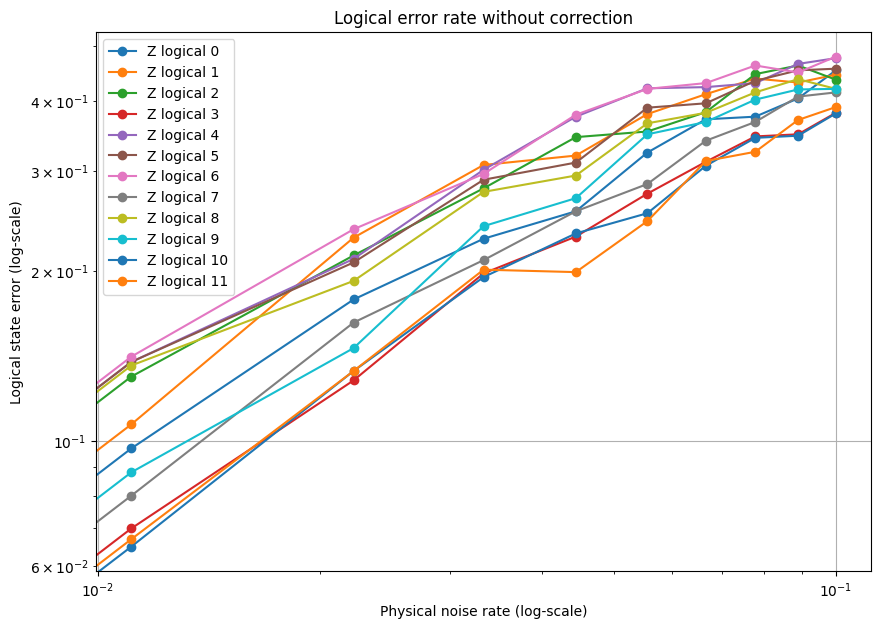

In [8]:
noise_levels = np.linspace(0, 0.1, 10)
logical_errors = []

z_logicals = BB_code.get_logical_ops(Pauli.Z)

for i in range(len(z_logicals)):
    n_qubits, n_data, n_edges, Hz, Hx = deform_code_for_logical(BB_code, Pauli.Z, i)

    logical_support = np.pad(z_logicals[i], (0, n_edges))

    errors = []
    for noise in noise_levels:
        error = get_logical_error_without_corrections(
            n_qubits=n_qubits,
            Hz=Hz,
            Hx=Hx,
            logical_mask=logical_support,
            noise_level=noise,
            logical_type=Pauli.Z,
        )
        errors.append(error)

    logical_errors.append(errors)

plt.figure(figsize=(10, 7))
for i, errors in enumerate(logical_errors):
    plt.loglog(noise_levels, errors, marker="o", label=f"Z logical {i}")

plt.xlabel("Physical noise rate (log-scale)")
plt.ylabel("Logical state error (log-scale)")
plt.title("Logical error rate without correction")
plt.legend()
plt.grid(True)
plt.show()

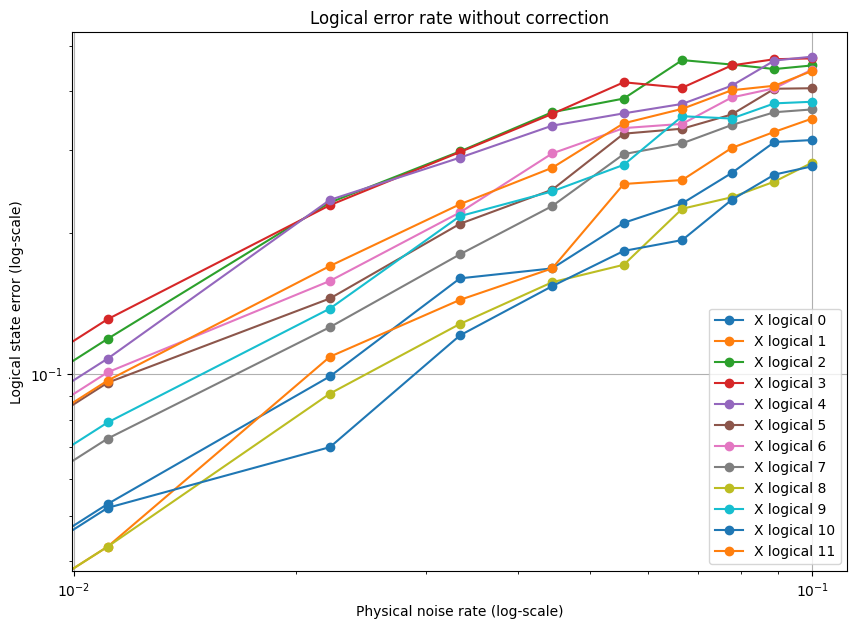

In [9]:
noise_levels = np.linspace(0, 0.1, 10)
logical_errors = []

x_logicals = BB_code.get_logical_ops(Pauli.X)

for i in range(len(x_logicals)):
    n_qubits, n_data, n_edges, Hx, Hz = deform_code_for_logical(BB_code, Pauli.X, i)

    logical_support = np.pad(x_logicals[i], (0, n_edges))

    errors = []
    for noise in noise_levels:
        error = get_logical_error_without_corrections(
            n_qubits=n_qubits,
            Hz=Hz,
            Hx=Hx,
            logical_mask=logical_support,
            noise_level=noise,
            logical_type=Pauli.X,
        )
        errors.append(error)

    logical_errors.append(errors)

plt.figure(figsize=(10, 7))
for i, errors in enumerate(logical_errors):
    plt.loglog(noise_levels, errors, marker="o", label=f"X logical {i}")

plt.xlabel("Physical noise rate (log-scale)")
plt.ylabel("Logical state error (log-scale)")
plt.title("Logical error rate without correction")
plt.legend()
plt.grid(True)
plt.show()